# 0. Load packages and data

In [2]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import igraph as ig
import leidenalg
#!pip install networkx-robustness
from networkx_robustness import networkx_robustness

G = nx.read_edgelist("data/ca-netscience.mtx", comments="%")

# 1. Descriptives

## 1.1 Basic Descriptives

In [3]:
#basics
print(f"\nNumber of nodes: {G.number_of_nodes()}")
print(f"\nNumber of edges: {G.number_of_edges()}")
print(f"\nNetwork density: {nx.density(G):.3f}")
print(f"\nIs connected: {nx.is_connected(G)}")
print(f"\nNumber of connected components: {nx.number_connected_components(G)}")


#averages shortest path
avg_path = nx.average_shortest_path_length(G)
print(f"\nAverage shortest path length: {avg_path:.3f}")

# Diameter (longest shortest path)
diameter = nx.diameter(G)
print(f"\nNetwork diameter: {diameter}")

# Global clustering coefficient (transitivity is another name)
#fraction of closed triangles on the repository
global_clustering = nx.transitivity(G) 
print(f"\nGlobal clustering coefficient (transitivity): {global_clustering:.4f}")

# Average local clustering coefficient
avg_clustering = nx.average_clustering(G)
print(f"\nAverage clustering coefficient: {avg_clustering:.4f}")



Number of nodes: 379

Number of edges: 914

Network density: 0.013

Is connected: True

Number of connected components: 1

Average shortest path length: 6.042

Network diameter: 17

Global clustering coefficient (transitivity): 0.4306

Average clustering coefficient: 0.7412


In [7]:
# Estimating Small World
sigma = nx.sigma(G, niter=5, nrand=10, seed= 42)
omega = nx.omega(G, niter=5, nrand=10, seed= 42)

print(sigma)
print(omega)

10.273107259113935
-0.38263826149242697


## 1.2 Degree

Average degree: 4.82
Median degree: 4.82
Max degree: 34.00
Lowest degree: 1.00

Node with highest degree: 4 (degree: 34)

Top 5 nodes by highest degree:
Node 4: 34
Node 5: 27
Node 26: 27
Node 16: 21
Node 67: 19

More than one node has the lowest degree, so we count the 
Number of nodes with lowest degree (1): 27


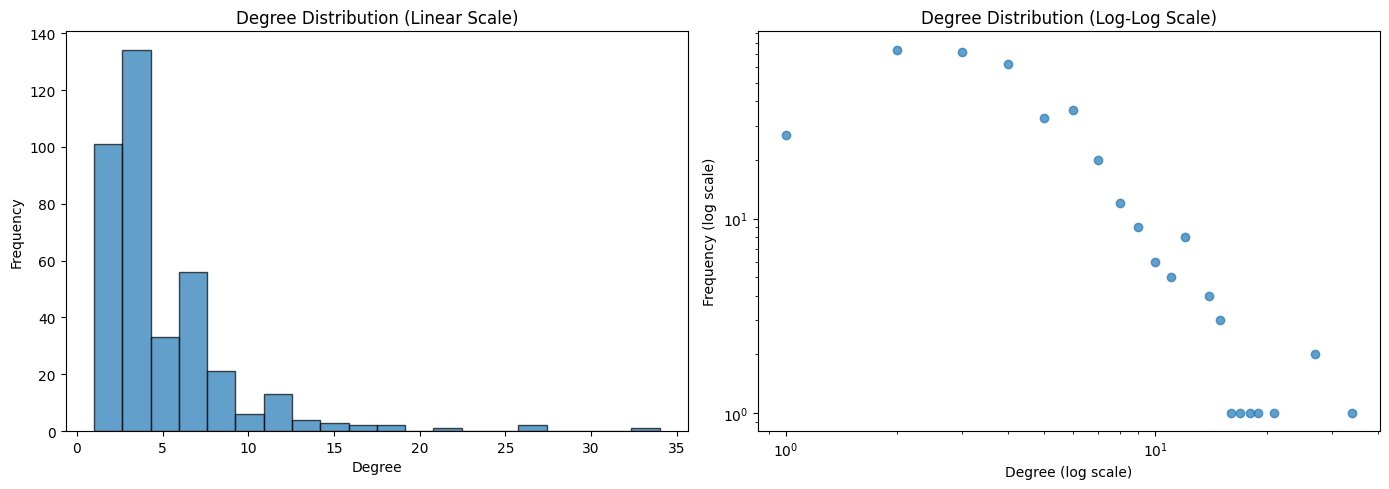

In [4]:
#DEGREE
degrees = dict(G.degree())

#average degree
mean_degree = np.mean(list(degrees.values()))
print(f"Average degree: {mean_degree:.2f}")

#median degree
median_degree = np.mean(list(degrees.values()))
print(f"Median degree: {median_degree:.2f}")

#highest degree
max_degree = np.max(list(degrees.values()))
print(f"Max degree: {max_degree:.2f}")

#min degree
min_degree = np.min(list(degrees.values()))
print(f"Lowest degree: {min_degree:.2f}")


max_degree_node = max(degrees, key=degrees.get)
print(f"\nNode with highest degree: {max_degree_node} (degree: {degrees[max_degree_node]})")

top_5_nodes = sorted(degrees.items(), key=lambda x: x[1], reverse=True)[:5]
print("\nTop 5 nodes by highest degree:")
for node, degree in top_5_nodes:
    print(f"Node {node}: {degree}")

#lowest degree
# more than one node has the lowest degree- lets count them
min_degree = min(degrees.values())
min_degree_nodes = sum(1 for d in degrees.values() if d == min_degree)
print(f"\nMore than one node has the lowest degree, so we count the \nNumber of nodes with lowest degree ({min_degree}): {min_degree_nodes}")


#visualization
degree_list = [d for n, d in G.degree()]

# Plot degree distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale
axes[0].hist(degree_list, bins=20, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Degree')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Degree Distribution (Linear Scale)')

# Log-log scale (useful for detecting power-law distributions)
degree_counts = pd.Series(degree_list).value_counts().sort_index()
axes[1].scatter(degree_counts.index, degree_counts.values, alpha=0.7)
axes[1].set_xlabel('Degree (log scale)')
axes[1].set_ylabel('Frequency (log scale)')
axes[1].set_title('Degree Distribution (Log-Log Scale)')
axes[1].set_xscale('log')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

## 1.3 Assortativity

Degree assortativity: -0.0817
Negative assortativity: high-degree nodes tend to connect to low-degree nodes


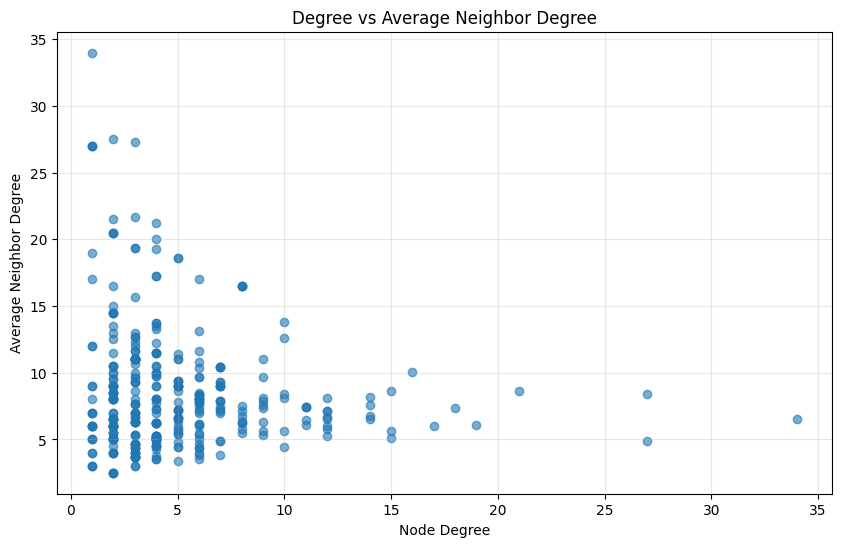

In [5]:
# Degree assortativity
degree_assortativity = nx.degree_assortativity_coefficient(G)
print(f"Degree assortativity: {degree_assortativity:.4f}")

if degree_assortativity > 0:
    print("Positive assortativity: high-degree nodes tend to connect to high-degree nodes")
elif degree_assortativity < 0:
    print("Negative assortativity: high-degree nodes tend to connect to low-degree nodes")
else:
    print("No degree assortativity")

avg_neighbor_degree = nx.average_neighbor_degree(G) # native function

# Plot relationship
node_degrees = dict(G.degree())

plt.figure(figsize=(10, 6))
plt.scatter([node_degrees[n] for n in G.nodes()],
           [avg_neighbor_degree[n] for n in G.nodes()],
           alpha=0.6)
plt.xlabel('Node Degree')
plt.ylabel('Average Neighbor Degree')
plt.title('Degree vs Average Neighbor Degree')
plt.grid(alpha=0.3)
plt.show()

## 1.4 Basic Visualization

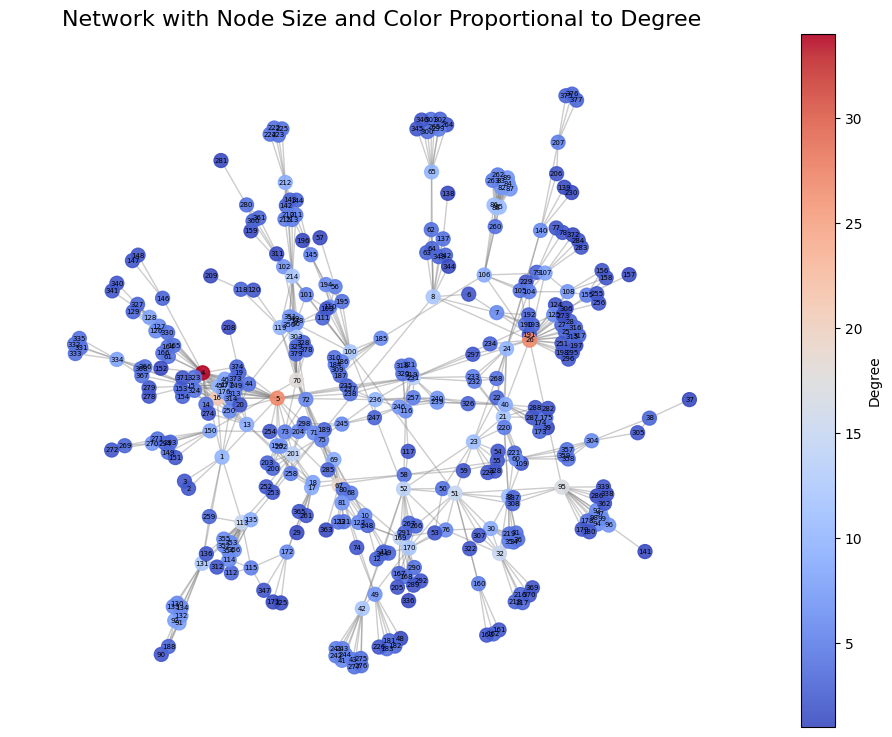

In [6]:
node_colors = [degrees[node] for node in G.nodes()]

plt.figure(figsize=(12, 9))
pos = nx.spring_layout(G, seed=42)

nodes_with_color = nx.draw_networkx_nodes(G, pos,node_color=node_colors, node_size=100, cmap=plt.cm.coolwarm,alpha=0.9)
nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.4)
nx.draw_networkx_labels(G, pos, font_size=5)

plt.colorbar(nodes_with_color, label='Degree')
plt.title('Network with Node Size and Color Proportional to Degree', fontsize=16)
plt.axis('off')
plt.show()

# 2. Centrality
Implementation of three centrality measure:
- betweenness centrality
- closeness centrality
- eigenvector centrality

to answer the following questions: 
- Which nodes are the researchers connectiing different research groups or departments? 
- Has written papers with many other researchers? 
- Who is conncted to well conncted researchers? 

## 2.1 Betweeness Centrality

1. 26 | Betweenness: 0.3972 | Degree: 27
2. 51 | Betweenness: 0.3451 | Degree: 15
3. 169 | Betweenness: 0.2860 | Degree: 14
4. 95 | Betweenness: 0.2702 | Degree: 17
5. 67 | Betweenness: 0.2554 | Degree: 19
6. 5 | Betweenness: 0.2506 | Degree: 27
7. 231 | Betweenness: 0.2317 | Degree: 14
8. 100 | Betweenness: 0.2215 | Degree: 12
9. 44 | Betweenness: 0.1749 | Degree: 4
10. 66 | Betweenness: 0.1747 | Degree: 6


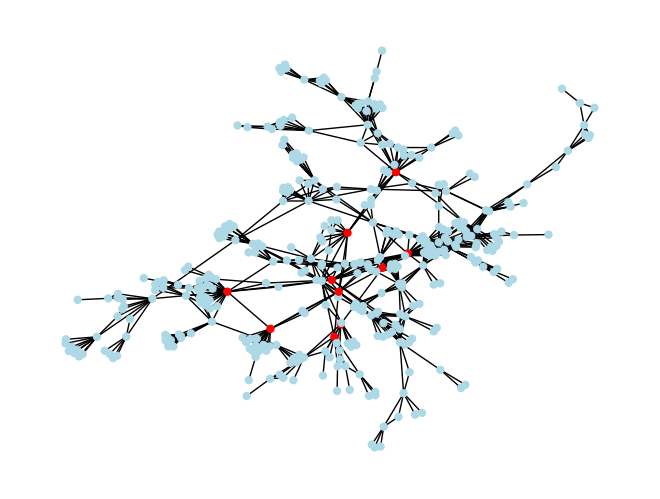

In [7]:
# Calculate betweenness centrality

betweenness = nx.betweenness_centrality(G, normalized=True) 

top_10_betweenness = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:10]

for i, (node, centrality) in enumerate(top_10_betweenness, 1):
    print(f"{i}. {node} | Betweenness: {centrality:.4f} | Degree: {degrees[node]}")

# normalized betweeness makes it comparable to other networks and can be interpeted as probabilities

# quick visualization to check the nodes
# Mark top 10 nodes
top_10_nodes = {node for node, _ in top_10_betweenness}

# Assign color attribute
for node in G.nodes():
    G.nodes[node]['color'] = 'red' if node in top_10_nodes else 'lightblue'

# Draw using the color attribute
colors = [G.nodes[node]['color'] for node in G.nodes()]
pos = nx.spring_layout(G)
nx.draw(G, node_color=colors, pos=pos, with_labels=False, node_size=25)
plt.show()

## 2.2 Eigenvector Centrality

In [8]:
# calculating the same for eigenvector centrality
eigenvector = nx.eigenvector_centrality(G, max_iter=1000) 
top_10_eigenvector = sorted(eigenvector.items(), key=lambda x: x[1], reverse=True)[:10]

print("\nTop 10 Researchers by Eigenvector Centrality:")
for i, (node, centrality) in enumerate(top_10_eigenvector, 1):
    print(f"{i}. {node} | Eigenvector: {centrality:.4f} | Degree: {degrees[node]}")

#interpretation: These researchers are connected to other well-connected researchers in the network.


Top 10 Researchers by Eigenvector Centrality:
1. 4 | Eigenvector: 0.4143 | Degree: 34
2. 5 | Eigenvector: 0.3562 | Degree: 27
3. 16 | Eigenvector: 0.3464 | Degree: 21
4. 15 | Eigenvector: 0.2557 | Degree: 16
5. 45 | Eigenvector: 0.2370 | Degree: 10
6. 46 | Eigenvector: 0.2182 | Degree: 8
7. 47 | Eigenvector: 0.2182 | Degree: 8
8. 176 | Eigenvector: 0.2182 | Degree: 8
9. 177 | Eigenvector: 0.2182 | Degree: 8
10. 250 | Eigenvector: 0.1471 | Degree: 6


## 2.3 Closeness Centrality

In [9]:
# Calculate closeness centrality
closeness = nx.closeness_centrality(G)
top_10_closeness = sorted(closeness.items(), key=lambda x: x[1], reverse=True)[:10]

print("\nTop 10 Researchers by Closeness Centrality:")
for i, (node, centrality) in enumerate(top_10_closeness, 1):
    print(f"{i}. {node} | Closeness: {centrality:.4f} | Degree: {degrees[node]}")

#Interpretation: These rearchers are centrally located in the network structure and can colloborate with other researchers over with the help of the fewest connections


Top 10 Researchers by Closeness Centrality:
1. 26 | Closeness: 0.2566 | Degree: 27
2. 95 | Closeness: 0.2490 | Degree: 17
3. 51 | Closeness: 0.2471 | Degree: 15
4. 231 | Closeness: 0.2431 | Degree: 14
5. 100 | Closeness: 0.2329 | Degree: 12
6. 52 | Closeness: 0.2306 | Degree: 14
7. 5 | Closeness: 0.2296 | Degree: 27
8. 44 | Closeness: 0.2224 | Degree: 4
9. 234 | Closeness: 0.2203 | Degree: 3
10. 297 | Closeness: 0.2199 | Degree: 2


## 2.4 Summary Centrality

In [10]:
# we add a local clustering coeffiicents to the centrality measurement to verfiy if nodes are within tighnitted communties or not

clustering = nx.clustering(G)

centrality_df = pd.DataFrame({
    'Node': list(G.nodes()),
    'Degree': [degrees[n] for n in G.nodes()],
    'Betweenness': [betweenness[n] for n in G.nodes()],
    'Eigenvector' : [eigenvector[n] for n in G.nodes()],
    'Closeness': [closeness[n] for n in G.nodes()],
    'Clustering' : [clustering[n] for n in G.nodes()]
})

centrality_df

,Node,Degree,Betweenness,Eigenvector,Closeness,Clustering
0,2,2,0.000000,0.014838,0.174919,1.000000
1,1,10,0.091461,0.139116,0.211765,0.266667
2,3,2,0.000000,0.014838,0.174919,1.000000
3,4,34,0.152056,0.414299,0.213318,0.133690
4,5,27,0.250628,0.356208,0.229648,0.182336
...,...,...,...,...,...,...
374,281,1,0.000000,0.000014,0.144440,0.000000
375,332,4,0.000000,0.004970,0.140782,1.000000
376,331,4,0.000000,0.004970,0.140782,1.000000
377,333,4,0.000000,0.004970,0.140782,1.000000


Correlation Matrix of Centrality Measures:
             Degree  Betweenness  Closeness  Eigenvector  Clustering
Degree        1.000        0.688      0.347        0.475      -0.362
Betweenness   0.688        1.000      0.430        0.188      -0.405
Closeness     0.347        0.430      1.000        0.259      -0.198
Eigenvector   0.475        0.188      0.259        1.000      -0.063
Clustering   -0.362       -0.405     -0.198       -0.063       1.000


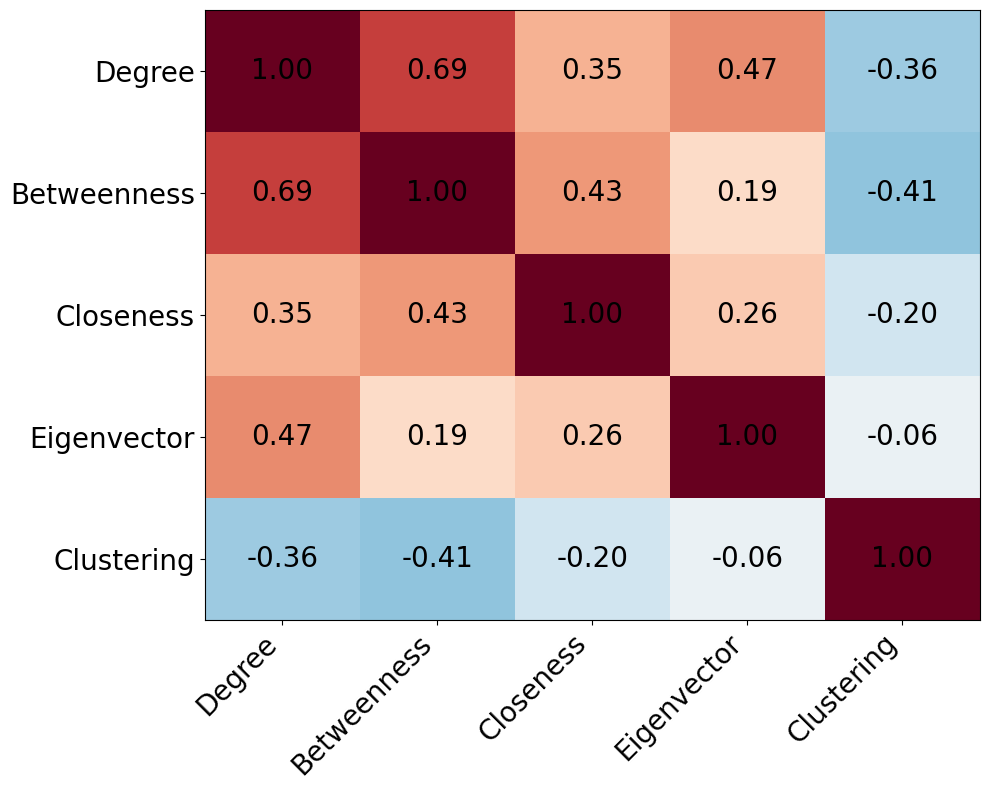

In [11]:
# Calculate correlation matrix
correlation_cols = ['Degree', 'Betweenness', 'Closeness', 'Eigenvector', 'Clustering']

correlation_matrix = centrality_df[correlation_cols].corr()

print("Correlation Matrix of Centrality Measures:")
print(correlation_matrix.round(3))

plt.figure(figsize=(10, 8))
plt.imshow(correlation_matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.xticks(range(len(correlation_cols)), correlation_cols, rotation=45, ha='right', fontsize=20)
plt.yticks(range(len(correlation_cols)), correlation_cols, fontsize=20)

# Add correlation values as text
for i in range(len(correlation_cols)):
    for j in range(len(correlation_cols)):
        plt.text(j, i, f'{correlation_matrix.iloc[i, j]:.2f}',
                ha='center', va='center', color='black', fontsize=20)

plt.tight_layout()
plt.show()

In [12]:
from scipy import stats
import itertools

for col1, col2 in itertools.combinations(correlation_cols, 2):
    r, p = stats.spearmanr(centrality_df[col1], centrality_df[col2])
    significance = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    print(f"{col1} vs {col2}: r={r:.3f}, p={p:.4f} {significance}")

Degree vs Betweenness: r=0.694, p=0.0000 ***
Degree vs Closeness: r=0.216, p=0.0000 ***
Degree vs Eigenvector: r=0.244, p=0.0000 ***
Degree vs Clustering: r=-0.298, p=0.0000 ***
Betweenness vs Closeness: r=0.328, p=0.0000 ***
Betweenness vs Eigenvector: r=0.206, p=0.0001 ***
Betweenness vs Clustering: r=-0.740, p=0.0000 ***
Closeness vs Eigenvector: r=0.531, p=0.0000 ***
Closeness vs Clustering: r=-0.208, p=0.0000 ***
Eigenvector vs Clustering: r=-0.086, p=0.0964 ns


# 3. Community Detection


Leiden:
  Communities: 19
  Modularity: 0.8486
  Average size: 19.9 researchers


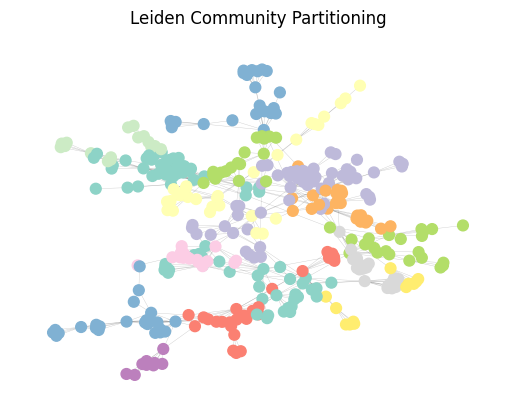

In [14]:
# Apply Leiden algorithm for community detection 
node_list = list(G.nodes())
node_to_idx = {node: idx for idx, node in enumerate(node_list)}
edges_idx = [(node_to_idx[u], node_to_idx[v]) for u, v in G.edges()]

g_ig = ig.Graph(n=len(node_list), edges=edges_idx)
leiden_result = leidenalg.find_partition(g_ig, leidenalg.ModularityVertexPartition, seed=42)

leiden_partition_lm = {node_list[i]: leiden_result.membership[i] for i in range(len(node_list))}
leiden_n_comm_lm = len(set(leiden_partition_lm.values()))

leiden_communities_lm = []
for comm_id in set(leiden_partition_lm.values()):
    leiden_communities_lm.append({node for node, c in leiden_partition_lm.items() if c == comm_id})
leiden_mod_lm = nx.community.modularity(G, leiden_communities_lm)

print(f"\nLeiden:")
print(f"  Communities: {leiden_n_comm_lm}")
print(f"  Modularity: {leiden_mod_lm:.4f}")
print(f"  Average size: {G.number_of_nodes() / leiden_n_comm_lm:.1f} researchers")


pos = nx.spring_layout(G, seed = 32)
nodes = list(G.nodes())
node_colors = [leiden_partition_lm[node] for node in nodes]

nx.draw_networkx_edges(G, pos, alpha=0.2, width=0.3)
nx.draw_networkx_nodes(G, pos, nodelist=nodes, node_color=node_colors, node_size=60, cmap=plt.cm.Set3)

plt.title('Leiden Community Partitioning', fontsize=12, pad=10)
plt.axis('off')
plt.show()

# 4. Robustness Study
We will check the robustness of the network by comparing random failures and targeted attacks on the top 10 nodes by centrality closeness. At each iteration we check if a giant component is still present. 

We use the networkx-robustness package https://github.com/tsantanam/networkx-robustness/tree/v0.0.7

Decription of the package: 

A package for simulating network attacks on NetworkX graphs. The current supported attacks include random attacks and targeted attacks on nodes with the highest degree centrality, betweenness centrality, closeness centrality, and eigenvector centrality. 

Attack functions return 
- the initial fraction of nodes in the giant component (**initial**)
- a list of the fraction of nodes in the giant component after each node removal, (**frac**)
- and a list of the average path length in the giant component after each node removal. (**apl**)


The package also contains functions for calculating the Molloy-Reed criterion and the critical threshold for a network.

In [28]:
#Simulate a random attack on 10 percent of the nodes
initial, frac_random, apl_random = networkx_robustness.simulate_random_attack(G, attack_fraction=0.1)

# we have to add the initial fraction at the start of each fraction list to make the plot more readable. 
frac_random = [initial] + frac_random

#Simulate a targeted attack on 10 percent of the nodes ordered by degree centrality
initial, frac_degree, apl_degree = networkx_robustness.simulate_degree_attack(G, attack_fraction=0.1)
frac_degree = [initial] + frac_degree

#Simulate a targeted attack on 10 percent of the nodes ordered by betweeness centrality
initial, frac_betweeness, apl_betweeness = networkx_robustness.simulate_betweenness_attack(G, attack_fraction=0.1)
frac_betweeness = [initial] + frac_betweeness

#Simulate a targeted attack on 10 percent of the nodes ordered by closeness centrality
initial, frac_closeness, apl_closeness = networkx_robustness.simulate_closeness_attack(G, attack_fraction=0.1)
frac_closeness = [initial] + frac_closeness

#Simulate a targeted attack on 10 percent of the nodes ordered by eigenvector centrality
initial, frac_eigen, apl_eigen = networkx_robustness.simulate_eigenvector_attack(G, attack_fraction=0.1)
frac_eigen = [initial] + frac_eigen


In [29]:
molloy_reed = networkx_robustness.molloy_reed(G)
print(molloy_reed)

critical_threshold = networkx_robustness.critical_threshold(G)
print(critical_threshold)

# doesnt work properly = result is None?
#manual implementation of the critical threshold

#calculate mean degrees of first and second neighbours 
#they have to be above 2 to gurantee a giant component
mean  = np.mean(degree_list)
mean_2 = np.mean([d**2 for d in degree_list])

#formula from class
fc = 1 - (mean / (mean_2 - mean))
print(f'Critical Threshold: {fc}')

8.020787746170678
None
Critical Threshold: 0.8575658407355462


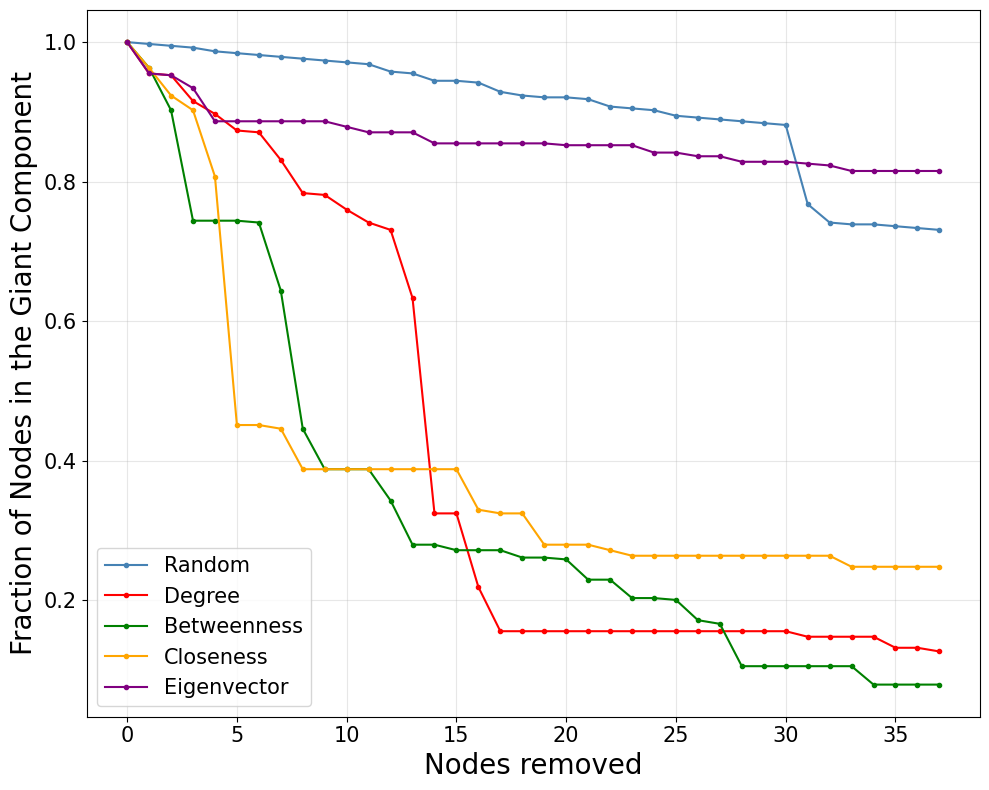

In [36]:
#visualize the different attack strategies by fraction of nodes within the giant component
strategies = {
    'Random':      frac_random,
    'Degree':      frac_degree,
    'Betweenness': frac_betweeness,
    'Closeness':   frac_closeness,
    'Eigenvector': frac_eigen  
}
colors = ['steelblue', 'red', 'green', 'orange', 'purple']

plt.figure(figsize=(10, 8))
for (label, data), color in zip(strategies.items(), colors):
    plt.plot(data, marker='o', markersize=3, label=label, color=color) 
plt.xlabel('Nodes removed', fontsize = 20)
plt.ylabel('Fraction of Nodes in the Giant Component', fontsize = 20)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.legend(fontsize = 15)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 5. Network Visualization
In this section we try to make a holisitic network visualization containing the following information: 
- communities marked by color
- marked high betweeness nodes to represent key connectors / researchers in the network
- degree (nodes size is proportional to their degree)

For this visualization we take data generated by the previous sections. Please be sure to run them beforehand.

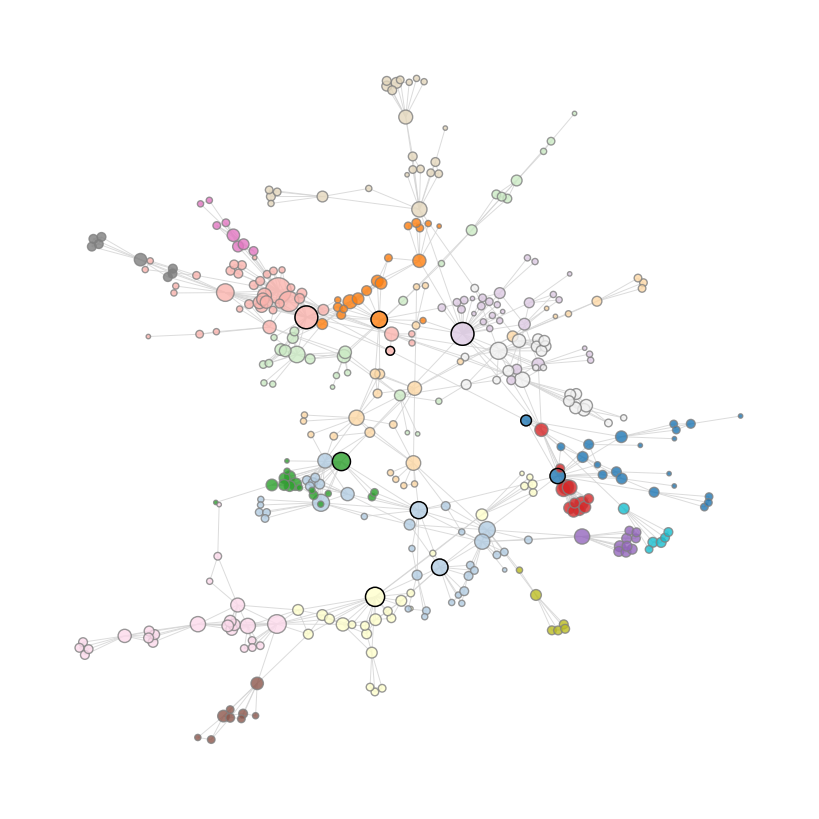

In [39]:
nodes = list(G.nodes())
node_colors = [leiden_partition_lm[node] for node in nodes]


# Scale node sizes  for better visibility)
node_sizes = [degrees[node] * 10 for node in G.nodes()]

# there are not enough colors in one color
# Get colors from multiple cmaps
from matplotlib.colors import ListedColormap
colors_pastel = plt.cm.Pastel1(np.linspace(0, 1, 9))    
colors_set = plt.cm.tab10(np.linspace(0, 1, 10))     

combined_colors = np.vstack([colors_pastel,colors_set])
custom_cmap = ListedColormap(combined_colors)


#draw graph 
plt.figure(figsize=(8, 8))
pos = nx.spring_layout(G, seed=32)
nx.draw(G, pos, node_size=node_sizes, node_color=node_colors, edge_color='lightgray', cmap=custom_cmap, linewidths=1,alpha=0.8, edgecolors='gray',width=0.7)

#include highest betweeness nodes and draw them only as an black ring overlay with a black ring to keep the colors of the previous layer
top_10_nodes = [node for node, _ in top_10_betweenness]
nx.draw_networkx_nodes(G, pos, nodelist=top_10_nodes,node_color='none',node_size=[degrees[n] * 10 for n in top_10_nodes],edgecolors='black',linewidths=1)

plt.axis('off')
plt.show()